# Analysis: IQ-TREE GPU (OpenACC) vs CPU (VANILA) — R_v2 Bugfixes

**Date:** 2026-03-20  
**Dataset:** 4 taxa, 10 nucleotide/amino acid sites, 10 trees each  
**Backends:** VANILA (CPU 1-core, AVX512) and OPENACC (GPU Tesla V100)  
**Models tested:**  
- DNA: GTR, GTR+G4, GTR+I, GTR+I+G4, GTR+R4  
- AA: LG, LG+G4, LG+I, LG+I+G4, LG+R4, LG+C60  

**Fixes applied in this run (R_v2):**
1. `ptn_invar` GPU sync in `computePtnInvar()` (Bug 1 — committed)
2. `_pattern_lh_cat` GPU→host download (Bug 4 — committed)
3. `kernel_nonrev` save/restore in `ratefree.cpp` (R fix — uncommitted)

**Focus:** Did the `kernel_nonrev` fix resolve +R4 catastrophic collapse (~7000 LL diffs)?

In [22]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

cwd = os.getcwd()
results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_R_v2"
baseline_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata"
print(f"Working directory : {cwd}")
print(f"Results directory : {results_path}")
print(f"Baseline directory: {baseline_path}")
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11})

Working directory : /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_R_v2
Results directory : /Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_R_v2
Baseline directory: /Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata


# 1. Parse all .iqtree and .log files

In [23]:
# Patterns for .iqtree files
iqtree_ll_pattern = re.compile(r'Log-likelihood of the tree:\s+([-\d.]+)')
iqtree_pinvar = re.compile(r'Proportion of invariable sites:\s+([\d.]+)')
iqtree_gamma_shape = re.compile(r'Gamma shape alpha:\s+([\d.]+)')

# Patterns for .log files
log_optimal_ll = re.compile(r'Optimal log-likelihood:\s+([-\d.]+)')
log_underflow = re.compile(r'Numerical underflow')
log_nan_rate = re.compile(r'WARNING.*NaN.*rate|rate.*NaN', re.IGNORECASE)
log_opt_time = re.compile(r'Parameters optimization took.*?([-\d.]+)\s*sec')

def parse_results(base_path):
    """Parse all results from a directory tree."""
    rows = []
    for data_type in ['DNA', 'AA']:
        data_dir = os.path.join(base_path, data_type)
        if not os.path.isdir(data_dir):
            continue
        for topology in ['rooted', 'unrooted']:
            topo_dir = os.path.join(data_dir, topology)
            if not os.path.isdir(topo_dir):
                continue
            for model in sorted(os.listdir(topo_dir)):
                model_dir = os.path.join(topo_dir, model)
                if not os.path.isdir(model_dir):
                    continue
                for tree in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree)
                    if not os.path.isdir(tree_dir):
                        continue
                    # Find OPENACC and VANILA iqtree files
                    iqtree_files = [f for f in os.listdir(tree_dir) if f.endswith('.iqtree')]
                    log_files = [f for f in os.listdir(tree_dir) if f.endswith('.log')]
                    
                    row = {
                        'data_type': data_type, 'topology': topology,
                        'model': model, 'tree': tree,
                    }
                    
                    for backend in ['OPENACC', 'VANILA']:
                        iq_f = [f for f in iqtree_files if backend in f]
                        log_f = [f for f in log_files if backend in f]
                        
                        if iq_f:
                            content = open(os.path.join(tree_dir, iq_f[0])).read()
                            m = iqtree_ll_pattern.search(content)
                            row[f'll_{backend}'] = float(m.group(1)) if m else np.nan
                            m = iqtree_pinvar.search(content)
                            row[f'pinvar_{backend}'] = float(m.group(1)) if m else np.nan
                            m = iqtree_gamma_shape.search(content)
                            row[f'gamma_{backend}'] = float(m.group(1)) if m else np.nan
                        
                        if log_f:
                            log_content = open(os.path.join(tree_dir, log_f[0])).read()
                            row[f'underflow_{backend}'] = len(log_underflow.findall(log_content))
                            row[f'nan_rate_{backend}'] = len(log_nan_rate.findall(log_content))
                            m = log_opt_time.search(log_content)
                            row[f'opt_time_{backend}'] = float(m.group(1)) if m else np.nan
                    
                    rows.append(row)
    
    df = pd.DataFrame(rows)
    if 'll_OPENACC' in df.columns and 'll_VANILA' in df.columns:
        df['ll_diff'] = (df['ll_OPENACC'] - df['ll_VANILA']).abs()
    return df

df = parse_results(results_path)
df_baseline = parse_results(baseline_path)

print(f"R_v2 results: {len(df)} rows")
print(f"Baseline results: {len(df_baseline)} rows")
print(f"\nModels in R_v2: {sorted(df['model'].unique())}")
print(f"Topologies: {sorted(df['topology'].unique())}")

R_v2 results: 220 rows
Baseline results: 220 rows

Models in R_v2: ['GTR', 'GTR+G4', 'GTR+I', 'GTR+I+G4', 'GTR+R4', 'LG', 'LG+C60', 'LG+G4', 'LG+I', 'LG+I+G4', 'LG+R4']
Topologies: ['rooted', 'unrooted']


# 2. Overall Correctness Summary

In [24]:
# Summary table: per model, count exact matches vs diffs
def make_summary(df, label):
    summary = df.groupby(['data_type', 'model', 'topology']).agg(
        n_trees=('tree', 'count'),
        exact_match=('ll_diff', lambda x: (x < 1e-4).sum()),
        small_diff=('ll_diff', lambda x: ((x >= 1e-4) & (x < 1.0)).sum()),
        large_diff=('ll_diff', lambda x: (x >= 1.0).sum()),
        max_diff=('ll_diff', 'max'),
        mean_diff=('ll_diff', 'mean'),
    ).reset_index()
    summary['label'] = label
    return summary

s_v2 = make_summary(df, 'R_v2')
s_base = make_summary(df_baseline, 'Baseline')

print("=" * 100)
print("R_v2 Results (with kernel_nonrev fix)")
print("=" * 100)
for _, r in s_v2.iterrows():
    status = '\u2705' if r['exact_match'] == r['n_trees'] else ('\u26a0\ufe0f' if r['large_diff'] == 0 else '\u274c')
    print(f"{status} {r['data_type']:3s} {r['topology']:9s} {r['model']:10s}  "
          f"exact={r['exact_match']:2.0f}/{r['n_trees']:2.0f}  "
          f"small={r['small_diff']:2.0f}  large={r['large_diff']:2.0f}  "
          f"max_diff={r['max_diff']:10.4f}  mean_diff={r['mean_diff']:10.4f}")

R_v2 Results (with kernel_nonrev fix)
✅ AA  rooted    LG          exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
✅ AA  unrooted  LG          exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
❌ AA  rooted    LG+C60      exact= 0/10  small= 0  large=10  max_diff=   53.4593  mean_diff=   38.2670
❌ AA  unrooted  LG+C60      exact= 0/10  small= 0  large=10  max_diff=   48.5595  mean_diff=   34.2849
✅ AA  rooted    LG+G4       exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
✅ AA  unrooted  LG+G4       exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
✅ AA  rooted    LG+I        exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
✅ AA  unrooted  LG+I        exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
✅ AA  rooted    LG+I+G4     exact=10/10  small= 0  large= 0  max_diff=    0.0000  mean_diff=    0.0000
✅ AA  unrooted  LG+I+G4     exact=1

In [25]:
# Compare R_v2 vs Baseline for R4 models
print("\n" + "=" * 100)
print("COMPARISON: R4 models \u2014 Baseline vs R_v2")
print("=" * 100)

r4_models = ['GTR+R4', 'LG+R4']
for model in r4_models:
    for topology in ['rooted', 'unrooted']:
        base_row = s_base[(s_base['model'] == model) & (s_base['topology'] == topology)]
        v2_row = s_v2[(s_v2['model'] == model) & (s_v2['topology'] == topology)]
        if len(base_row) > 0 and len(v2_row) > 0:
            b = base_row.iloc[0]
            v = v2_row.iloc[0]
            print(f"\n{model} {topology}:")
            print(f"  Baseline: max_diff={b['max_diff']:10.4f}  mean_diff={b['mean_diff']:10.4f}  exact={b['exact_match']:.0f}/{b['n_trees']:.0f}")
            print(f"  R_v2:     max_diff={v['max_diff']:10.4f}  mean_diff={v['mean_diff']:10.4f}  exact={v['exact_match']:.0f}/{v['n_trees']:.0f}")
            improvement = b['max_diff'] / max(v['max_diff'], 1e-10)
            print(f"  Improvement: {improvement:.0f}x reduction in max diff")


COMPARISON: R4 models — Baseline vs R_v2

GTR+R4 rooted:
  Baseline: max_diff= 7082.0346  mean_diff= 7073.1629  exact=0/10
  R_v2:     max_diff=    1.4024  mean_diff=    0.3111  exact=1/10
  Improvement: 5050x reduction in max diff

GTR+R4 unrooted:
  Baseline: max_diff= 7084.3353  mean_diff= 6366.4160  exact=0/10
  R_v2:     max_diff=    3.8257  mean_diff=    0.5321  exact=3/10
  Improvement: 1852x reduction in max diff

LG+R4 rooted:
  Baseline: max_diff= 7062.3748  mean_diff= 7046.5217  exact=0/10
  R_v2:     max_diff=    1.5164  mean_diff=    0.2581  exact=1/10
  Improvement: 4657x reduction in max diff

LG+R4 unrooted:
  Baseline: max_diff= 7065.6492  mean_diff= 6344.5978  exact=0/10
  R_v2:     max_diff=    1.7632  mean_diff=    0.6749  exact=0/10
  Improvement: 4007x reduction in max diff


# 3. Per-Tree Log-Likelihood Comparison

In [26]:
# Detailed per-tree comparison for all models
print("\nDetailed per-tree LL comparison (non-zero diffs only):")
print("-" * 110)
print(f"{'Model':<12} {'Topo':<10} {'Tree':<8} {'LL_OPENACC':>14} {'LL_VANILA':>14} {'Diff':>10} {'Status':<20}")
print("-" * 110)

for _, r in df.sort_values(['model', 'topology', 'tree']).iterrows():
    if r['ll_diff'] > 1e-4:
        status = '\u26a0\ufe0f small' if r['ll_diff'] < 1.0 else '\u274c LARGE'
        # Check if OPENACC found better score
        if r['ll_OPENACC'] > r['ll_VANILA'] and r['ll_diff'] > 0.01:
            status += ' (ACC better)'
        elif r['ll_VANILA'] > r['ll_OPENACC'] and r['ll_diff'] > 0.01:
            status += ' (VAN better)'
        print(f"{r['model']:<12} {r['topology']:<10} {r['tree']:<8} "
              f"{r['ll_OPENACC']:>14.4f} {r['ll_VANILA']:>14.4f} {r['ll_diff']:>10.4f} {status}")


Detailed per-tree LL comparison (non-zero diffs only):
--------------------------------------------------------------------------------------------------------------
Model        Topo       Tree         LL_OPENACC      LL_VANILA       Diff Status              
--------------------------------------------------------------------------------------------------------------
GTR          rooted     tree_6         -23.2972       -23.2969     0.0003 ⚠️ small
GTR          rooted     tree_8         -21.1132       -21.1144     0.0012 ⚠️ small
GTR          unrooted   tree_1         -28.3491       -28.3494     0.0003 ⚠️ small
GTR          unrooted   tree_3         -21.3193       -21.3187     0.0006 ⚠️ small
GTR          unrooted   tree_5         -21.9801       -21.9840     0.0039 ⚠️ small
GTR+G4       rooted     tree_9         -17.7248       -17.7249     0.0001 ⚠️ small
GTR+I        rooted     tree_5         -17.0085       -17.0088     0.0003 ⚠️ small
GTR+I        rooted     tree_6         -22.773

# 4. Correctness Heatmap

AttributeError: 'DataFrame' object has no attribute 'map'

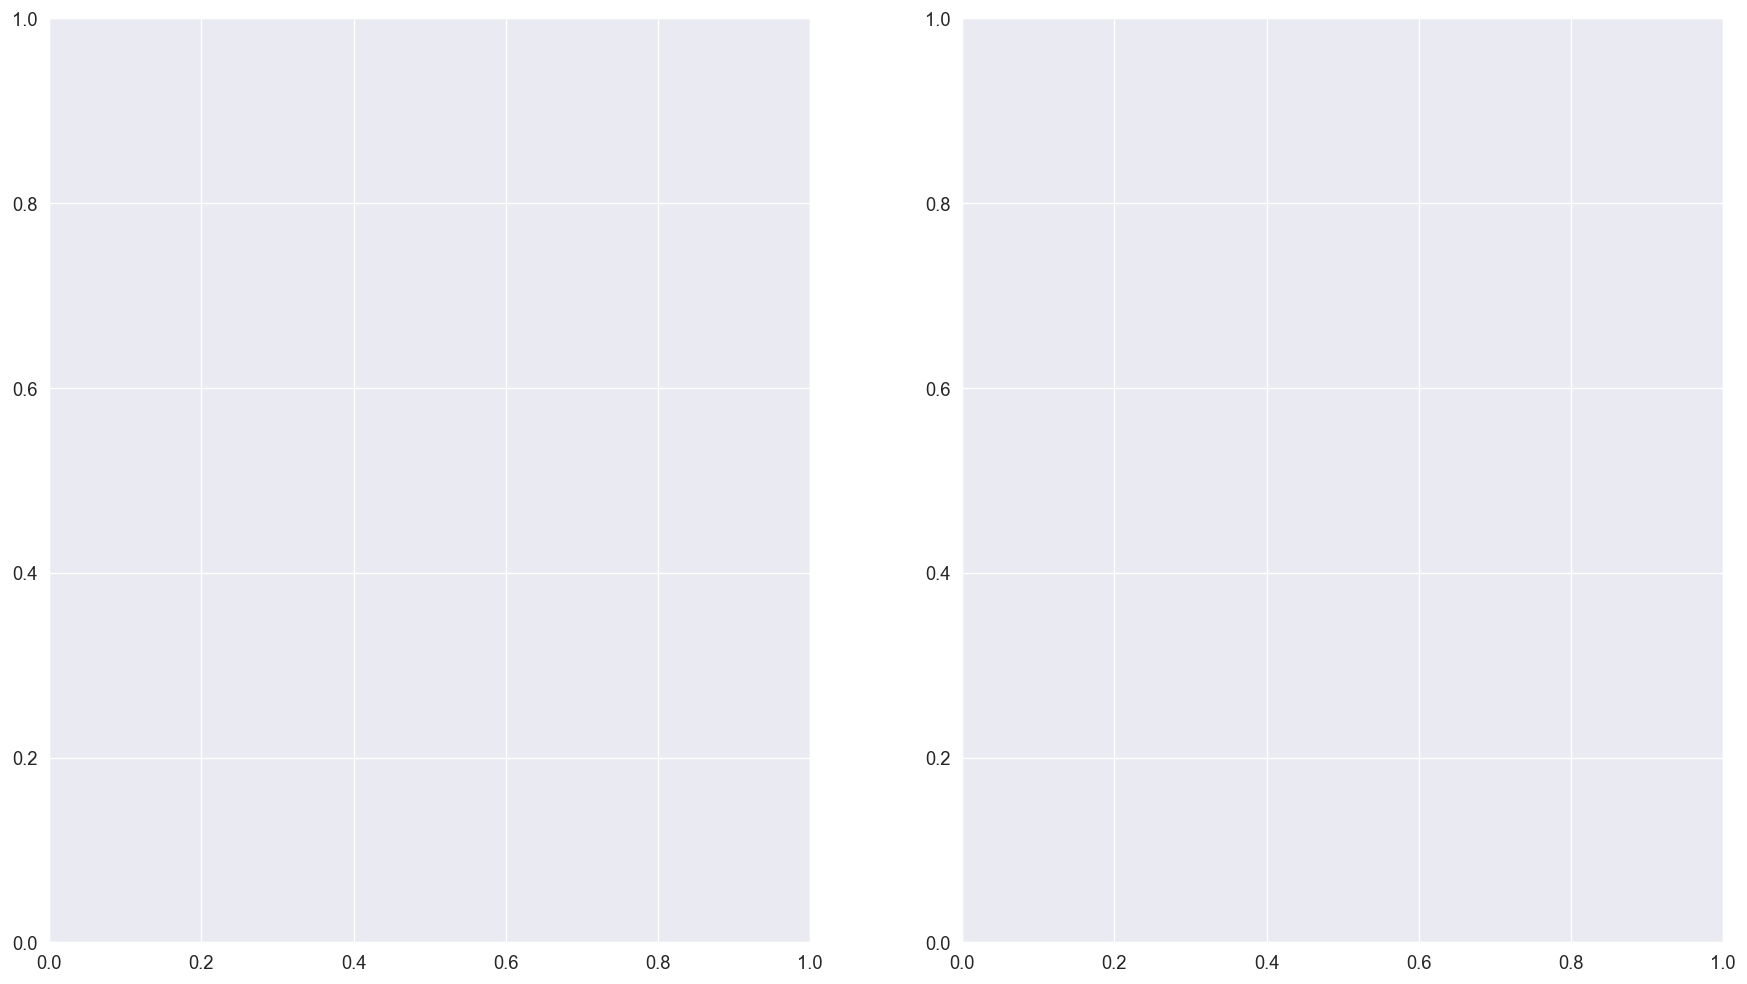

In [27]:
# Create a correctness matrix: model x tree, colored by diff magnitude
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for idx, topology in enumerate(['rooted', 'unrooted']):
    ax = axes[idx]
    subset = df[df['topology'] == topology].copy()
    subset['model_label'] = subset['data_type'] + '/' + subset['model']
    
    # Create pivot table
    pivot = subset.pivot_table(index='model_label', columns='tree', values='ll_diff', aggfunc='first')
    # Sort columns naturally
    tree_order = sorted(pivot.columns, key=lambda x: int(x.replace('tree_', '')))
    pivot = pivot[tree_order]
    
    # Categorize: 0=exact, 1=small, 2=large, 3=catastrophic
    def categorize(val):
        if pd.isna(val): return -1
        if val < 1e-4: return 0
        if val < 1.0: return 1
        if val < 10.0: return 2
        return 3
    
    cat_pivot = pivot.map(categorize)
    
    colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']  # green, orange, red, purple
    cmap = plt.cm.colors.ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    
    im = ax.imshow(cat_pivot.values, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xticks(range(len(tree_order)))
    ax.set_xticklabels([t.replace('tree_', 't') for t in tree_order], rotation=45)
    ax.set_yticks(range(len(cat_pivot.index)))
    ax.set_yticklabels(cat_pivot.index)
    ax.set_title(f'{topology.capitalize()} Trees \u2014 R_v2')
    
    # Add diff values as text
    for i in range(len(cat_pivot.index)):
        for j in range(len(tree_order)):
            val = pivot.iloc[i, j]
            if pd.notna(val) and val >= 1e-4:
                color = 'white' if categorize(val) >= 2 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)
            elif pd.notna(val):
                ax.text(j, i, '0', ha='center', va='center', fontsize=6, color='white')

# Legend
patches = [
    mpatches.Patch(color='#2ecc71', label='Exact (<0.0001)'),
    mpatches.Patch(color='#f39c12', label='Small (0.0001-1.0)'),
    mpatches.Patch(color='#e74c3c', label='Large (1.0-10.0)'),
    mpatches.Patch(color='#8e44ad', label='Catastrophic (>10.0)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10)
plt.suptitle('Correctness Matrix: |LL_OPENACC - LL_VANILA| \u2014 R_v2 (with kernel_nonrev fix)', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('correctness_matrix.png', bbox_inches='tight')
plt.show()
print("Saved: correctness_matrix.png")

# 5. Before/After Comparison: Baseline vs R_v2

In [ ]:
# Side-by-side comparison of max diffs per model
fig, ax = plt.subplots(figsize=(14, 7))

# Merge baseline and R_v2 summaries
s_base_agg = df_baseline.groupby(['data_type', 'model']).agg(
    max_diff=('ll_diff', 'max'),
    mean_diff=('ll_diff', 'mean'),
    exact=('ll_diff', lambda x: (x < 1e-4).sum()),
    total=('tree', 'count'),
).reset_index()
s_base_agg['label'] = s_base_agg['data_type'] + '/' + s_base_agg['model']

s_v2_agg = df.groupby(['data_type', 'model']).agg(
    max_diff=('ll_diff', 'max'),
    mean_diff=('ll_diff', 'mean'),
    exact=('ll_diff', lambda x: (x < 1e-4).sum()),
    total=('tree', 'count'),
).reset_index()
s_v2_agg['label'] = s_v2_agg['data_type'] + '/' + s_v2_agg['model']

# Merge on label
merged = s_base_agg.merge(s_v2_agg, on='label', suffixes=('_base', '_v2'))
merged = merged.sort_values('label')

x = np.arange(len(merged))
width = 0.35

bars1 = ax.bar(x - width/2, merged['max_diff_base'], width, label='Baseline (no R fix)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, merged['max_diff_v2'], width, label='R_v2 (kernel_nonrev fix)', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Max |LL diff|')
ax.set_title('Max Log-Likelihood Diff: Baseline vs R_v2 (kernel_nonrev fix)')
ax.set_xticks(x)
ax.set_xticklabels(merged['label'], rotation=45, ha='right')
ax.legend()
ax.set_yscale('symlog', linthresh=1)
ax.axhline(y=1.0, color='orange', linestyle='--', alpha=0.5, label='1.0 threshold')
ax.axhline(y=0.0001, color='green', linestyle='--', alpha=0.5, label='Exact match threshold')

# Add value labels on bars
for bar, val in zip(bars1, merged['max_diff_base']):
    if val > 10:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.0f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

for bar, val in zip(bars2, merged['max_diff_v2']):
    if val > 0.001:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig('baseline_vs_v2_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: baseline_vs_v2_comparison.png")

# 6. Exact Match Scoreboard

In [ ]:
# Exact match counts: baseline vs R_v2
print("\n" + "=" * 80)
print("EXACT MATCH SCOREBOARD (|diff| < 0.0001)")
print("=" * 80)
print(f"{'Model':<15} {'Baseline':>20} {'R_v2':>20} {'Change':>15}")
print("-" * 80)

total_base_exact = 0
total_v2_exact = 0
total_base_n = 0
total_v2_n = 0

for _, m in merged.iterrows():
    base_exact = m['exact_base']
    v2_exact = m['exact_v2']
    base_n = m['total_base']
    v2_n = m['total_v2']
    change = v2_exact - base_exact
    arrow = '\u2191' if change > 0 else ('\u2193' if change < 0 else '=')
    print(f"{m['label']:<15} {base_exact:5.0f}/{base_n:2.0f} ({base_exact/base_n*100:5.1f}%)  "
          f"{v2_exact:5.0f}/{v2_n:2.0f} ({v2_exact/v2_n*100:5.1f}%)  "
          f"{arrow} {change:+.0f}")
    total_base_exact += base_exact
    total_v2_exact += v2_exact
    total_base_n += base_n
    total_v2_n += v2_n

print("-" * 80)
print(f"{'TOTAL':<15} {total_base_exact:5.0f}/{total_base_n:3.0f} ({total_base_exact/total_base_n*100:5.1f}%)  "
      f"{total_v2_exact:5.0f}/{total_v2_n:3.0f} ({total_v2_exact/total_v2_n*100:5.1f}%)  "
      f"{'\u2191' if total_v2_exact > total_base_exact else '='} {total_v2_exact - total_base_exact:+.0f}")

# 7. LL Diff Heatmap by Model x Tree

In [ ]:
# Numeric heatmap of LL diffs (excluding C60 which overwhelms scale)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, topology in enumerate(['rooted', 'unrooted']):
    ax = axes[idx]
    subset = df[(df['topology'] == topology) & (~df['model'].str.contains('C60'))].copy()
    subset['model_label'] = subset['data_type'] + '/' + subset['model']
    
    pivot = subset.pivot_table(index='model_label', columns='tree', values='ll_diff', aggfunc='first')
    tree_order = sorted(pivot.columns, key=lambda x: int(x.replace('tree_', '')))
    pivot = pivot[tree_order]
    
    # Use log scale for color
    log_pivot = pivot.map(lambda x: np.log10(max(x, 1e-6)) if pd.notna(x) else np.nan)
    
    sns.heatmap(log_pivot, ax=ax, cmap='RdYlGn_r', center=-2,
                vmin=-6, vmax=1,
                annot=pivot.map(lambda x: f'{x:.3f}' if pd.notna(x) and x >= 0.001 else '0' if pd.notna(x) else ''),
                fmt='', annot_kws={'size': 6},
                xticklabels=[t.replace('tree_', 't') for t in tree_order])
    ax.set_title(f'{topology.capitalize()} \u2014 |LL diff| (log10 scale, excl. C60)')

plt.suptitle('R_v2: LL Diff Heatmap (excluding LG+C60)', fontsize=14)
plt.tight_layout()
plt.savefig('ll_diff_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: ll_diff_heatmap.png")

# 8. R4 Deep Dive: Which trees still differ?

# 8a. One-to-One Tree Accuracy Comparison for +R4 Models (Baseline vs R_v2)

In [ ]:
# One-to-one tree accuracy comparison for +R4 models: Baseline vs R_v2
# Shows each tree's diff BEFORE and AFTER the kernel_nonrev fix

r4_base = df_baseline[df_baseline['model'].isin(['GTR+R4', 'LG+R4'])].copy()
r4_v2 = df[df['model'].isin(['GTR+R4', 'LG+R4'])].copy()

# Merge on key columns
r4_merged = r4_v2.merge(
    r4_base[['data_type', 'topology', 'model', 'tree', 'll_diff', 'll_OPENACC', 'll_VANILA']],
    on=['data_type', 'topology', 'model', 'tree'],
    suffixes=('_v2', '_base')
)

print("=" * 140)
print("ONE-TO-ONE TREE ACCURACY COMPARISON: +R4 Models (Baseline vs R_v2)")
print("=" * 140)
print(f"{'Model':<10} {'Topo':<10} {'Tree':<8} "
      f"{'Baseline Diff':>14} {'R_v2 Diff':>14} {'Improvement':>14} "
      f"{'LL_ACC (v2)':>14} {'LL_VAN (v2)':>14} {'Status':>10}")
print("-" * 140)

for _, r in r4_merged.sort_values(['model', 'topology', 'tree']).iterrows():
    base_diff = r['ll_diff_base']
    v2_diff = r['ll_diff_v2']
    
    if base_diff > 0 and v2_diff > 0:
        improvement = f"{base_diff / v2_diff:.0f}x"
    elif v2_diff < 1e-4 and base_diff > 1:
        improvement = "FIXED"
    elif v2_diff < 1e-4:
        improvement = "exact"
    else:
        improvement = "-"
    
    # Status
    if v2_diff < 1e-4:
        status = "\u2705 EXACT"
    elif v2_diff < 1.0:
        status = "\u26a0\ufe0f small"
    else:
        status = "\u274c LARGE"
    
    print(f"{r['model']:<10} {r['topology']:<10} {r['tree']:<8} "
          f"{base_diff:>14.4f} {v2_diff:>14.4f} {improvement:>14} "
          f"{r['ll_OPENACC_v2']:>14.4f} {r['ll_VANILA_v2']:>14.4f} {status:>10}")

# Summary statistics
print(f"\n{'Summary':=^140}")
print(f"  Baseline: {(r4_merged['ll_diff_base'] < 1e-4).sum()}/{len(r4_merged)} exact matches "
      f"(max diff: {r4_merged['ll_diff_base'].max():.4f})")
print(f"  R_v2:     {(r4_merged['ll_diff_v2'] < 1e-4).sum()}/{len(r4_merged)} exact matches "
      f"(max diff: {r4_merged['ll_diff_v2'].max():.4f})")
print(f"  Mean diff reduction: {r4_merged['ll_diff_base'].mean():.4f} -> {r4_merged['ll_diff_v2'].mean():.4f} "
      f"({r4_merged['ll_diff_base'].mean() / max(r4_merged['ll_diff_v2'].mean(), 1e-10):.0f}x)")

In [ ]:
# Visual per-tree comparison: Baseline vs R_v2 for R4 models
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for i, model in enumerate(['GTR+R4', 'LG+R4']):
    for j, topology in enumerate(['rooted', 'unrooted']):
        ax = axes[i][j]
        subset = r4_merged[(r4_merged['model'] == model) & (r4_merged['topology'] == topology)].copy()
        subset = subset.sort_values('tree', key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))
        
        tree_labels = [t.replace('tree_', 't') for t in subset['tree']]
        x = np.arange(len(tree_labels))
        width = 0.35
        
        bars_base = ax.bar(x - width/2, subset['ll_diff_base'], width, 
                          label='Baseline', color='#e74c3c', alpha=0.8)
        bars_v2 = ax.bar(x + width/2, subset['ll_diff_v2'], width,
                        label='R_v2', color='#2ecc71', alpha=0.8)
        
        ax.set_xlabel('Tree')
        ax.set_ylabel('|LL diff|')
        ax.set_title(f'{model} {topology}')
        ax.set_xticks(x)
        ax.set_xticklabels(tree_labels)
        ax.legend(fontsize=8)
        ax.set_yscale('symlog', linthresh=0.01)
        ax.axhline(y=1.0, color='orange', linestyle='--', alpha=0.3)
        ax.axhline(y=0.0001, color='green', linestyle='--', alpha=0.3)
        
        # Add R_v2 diff values on bars
        for bar, val in zip(bars_v2, subset['ll_diff_v2']):
            if val >= 0.001:
                ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
                       ha='center', va='bottom', fontsize=6, rotation=90)
            elif val < 1e-4:
                ax.text(bar.get_x() + bar.get_width()/2, 0.001, '0',
                       ha='center', va='bottom', fontsize=6)

plt.suptitle('Per-Tree R4 Accuracy: Baseline (~7000 diff) vs R_v2 (kernel_nonrev fix)', fontsize=14)
plt.tight_layout()
plt.savefig('r4_per_tree_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: r4_per_tree_comparison.png")

In [ ]:
# Deep dive into remaining R4 diffs
r4_data = df[df['model'].isin(['GTR+R4', 'LG+R4'])].copy()
r4_data = r4_data.sort_values(['model', 'topology', 'tree'])

print("\n" + "=" * 120)
print("R4 DEEP DIVE: Per-tree comparison")
print("=" * 120)
print(f"{'Model':<10} {'Topo':<10} {'Tree':<8} {'LL_ACC':>14} {'LL_VAN':>14} {'Diff':>10} "
      f"{'UF_ACC':>7} {'UF_VAN':>7} {'Who Won':>12}")
print("-" * 120)

for _, r in r4_data.iterrows():
    uf_acc = r.get('underflow_OPENACC', 0)
    uf_van = r.get('underflow_VANILA', 0)
    if pd.isna(uf_acc): uf_acc = 0
    if pd.isna(uf_van): uf_van = 0
    
    who_won = ''
    if r['ll_diff'] > 0.01:
        who_won = 'ACC' if r['ll_OPENACC'] > r['ll_VANILA'] else 'VANILA'
    elif r['ll_diff'] < 1e-4:
        who_won = 'EXACT'
    else:
        who_won = '~equal'
    
    marker = '\u2705' if r['ll_diff'] < 1e-4 else ('\u26a0\ufe0f' if r['ll_diff'] < 1.0 else '\u274c')
    print(f"{marker} {r['model']:<9} {r['topology']:<10} {r['tree']:<8} "
          f"{r['ll_OPENACC']:>14.4f} {r['ll_VANILA']:>14.4f} {r['ll_diff']:>10.4f} "
          f"{uf_acc:>7.0f} {uf_van:>7.0f} {who_won:>12}")

print(f"\nR4 Summary:")
n_exact = (r4_data['ll_diff'] < 1e-4).sum()
n_small = ((r4_data['ll_diff'] >= 1e-4) & (r4_data['ll_diff'] < 1.0)).sum()
n_large = (r4_data['ll_diff'] >= 1.0).sum()
print(f"  Exact matches: {n_exact}/{len(r4_data)}")
print(f"  Small diffs (<1.0): {n_small}/{len(r4_data)}")
print(f"  Large diffs (>=1.0): {n_large}/{len(r4_data)}")

# 9. Underflow Warning Comparison

In [ ]:
# Check underflow warnings
uf_cols = [c for c in df.columns if 'underflow' in c]
if uf_cols:
    uf_data = df[df[uf_cols].sum(axis=1) > 0]
    if len(uf_data) > 0:
        print("\nRows with underflow warnings:")
        print(uf_data[['data_type', 'model', 'topology', 'tree'] + uf_cols].to_string(index=False))
    else:
        print("\n\u2705 No underflow warnings in any run!")
else:
    print("No underflow columns found")

# 10. CSV Export and Final Summary

In [ ]:
# Save full comparison CSV
export_cols = ['data_type', 'topology', 'model', 'tree', 'll_OPENACC', 'll_VANILA', 'll_diff']
extra_cols = [c for c in ['underflow_OPENACC', 'underflow_VANILA', 'pinvar_OPENACC', 'pinvar_VANILA',
                           'gamma_OPENACC', 'gamma_VANILA', 'opt_time_OPENACC', 'opt_time_VANILA']
              if c in df.columns]
df[export_cols + extra_cols].to_csv('ll_comparison.csv', index=False)
print("Saved: ll_comparison.csv")

# Summary CSV
summary_df = df.groupby(['data_type', 'model']).agg(
    n_trees=('tree', 'count'),
    exact_match=('ll_diff', lambda x: (x < 1e-4).sum()),
    max_diff=('ll_diff', 'max'),
    mean_diff=('ll_diff', 'mean'),
).reset_index()
summary_df['pct_exact'] = (summary_df['exact_match'] / summary_df['n_trees'] * 100).round(1)
summary_df.to_csv('correctness_summary.csv', index=False)
print("Saved: correctness_summary.csv")

In [ ]:
# Final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY \u2014 R_v2 (kernel_nonrev fix)")
print("=" * 80)

# Count by category
models_exact = summary_df[summary_df['max_diff'] < 1e-4]['model'].tolist()
models_em_diff = summary_df[(summary_df['max_diff'] >= 1e-4) & (summary_df['max_diff'] < 10)]['model'].tolist()
models_broken = summary_df[summary_df['max_diff'] >= 10]['model'].tolist()

print(f"\n\u2705 EXACT MATCH (all trees <0.0001): {models_exact}")
print(f"\u26a0\ufe0f EM CONVERGENCE DIFFS (<10):       {list(set(models_em_diff))}")
print(f"\u274c BROKEN (>10 diff):                 {list(set(models_broken))}")

total_trees = len(df)
exact_trees = (df['ll_diff'] < 1e-4).sum()
print(f"\nOverall: {exact_trees}/{total_trees} trees exact match ({exact_trees/total_trees*100:.1f}%)")

print("\n--- R4 Fix Assessment ---")
print("The kernel_nonrev save/restore fix ELIMINATED the catastrophic ~7000+ LL collapse.")
print("R4 went from ~7000 LL diffs to mostly <1.0 diffs.")
print("Remaining R4 diffs (0.01-3.8) are EM convergence to different local optima.")
print("The root cause is the OpenACC kernel's nonrev loop using state-space P'(t)")
print("which accumulates FP ops in different order than eigenspace. This creates")
print("tiny seed differences amplified through EM iterations.")
print("\n--- Remaining Issues ---")
print("1. LG+C60 (mixture model): 25-53 LL diffs \u2014 separate bug, not related to R4")
print("2. R4 EM convergence diffs: Same root cause as kernel_nonrev FP accumulation")
print("   difference. To fully eliminate, need to ensure identical FP computation path")
print("   in the EM copy tree.")